# <CENTER> **PROJECT - WINE QUALITY**
<CENTER> ----------------------------------------------------------------

---

#### **Постановка задачи:**

В данной работе необходимо по имеющимся данным научиться определять качество вина. Необходимо решить задачу классификации с использованием `SVM` и подобрать наилучшее ядро.

---


#### **Основные цели:**

* Сформировать набор данных на основе предоставленных источников информации;

* Спроектировать новые признаки с помощью *Feature Engineering* и выявить наиболее значимые при построении модели;

* Исследовать предоставленные данные и выявить закономерности;

* Обучить модель `SVM` и получить значение метрики на валидации..

---


#### **Этапы работы над проектом:**

Проект будет состоять из семи частей:

`1.` *Базовый анализ и знакомство с данными*;

`2.` *Предобработка и очистка данных*;

`3.` *Разведывательный анализ данных (EDA)*;

`4.` *Feature engineering (Создание новых признаков)*;

`5.` *Machine Learning*;

`6.` *Мониторинг модели*;

`7.` *Вывод*.

---

**Импортируем необходимые библиотеки:**

In [1]:
# Для работы с данными
import numpy as np 
import pandas as pd 
from imblearn import over_sampling   # для балансировки классов
from imblearn import pipeline
from scipy import stats
import time
import joblib


# Для построения графиков
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns


# Для создания и обучения модели
from sklearn import preprocessing
from sklearn import compose
from sklearn import model_selection
from sklearn import svm


# Для работы с метриками
from sklearn import metrics
from prometheus_client import start_http_server, Gauge, Counter

**Загружаем данные:**

In [3]:
# Загружаем датасет
winequality_data = pd.read_csv('data/winequality-red.csv', sep = ';')

# Создаём копию
winequality_df = winequality_data.copy()

=============================================================================================================================================

## <center> **`1.` Базовый анализ и знакомство с данными**

На данном этапе изучим информацию предоставленных данных.

#### $1.1$

**Выведем информацию по таблицам.**

Создаём функцию:

In [4]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print(f'\nДанные таблицы "{data_name}" имеют следующую размерность:\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем первые пять строк 
    display(data)
    print('-' * length2)

Выводим результат:

In [5]:
# Выводим информацию по полученной таблице при помощи функции 'check_data_inf'
check_data_inf(
    data = winequality_df,
    data_name = 'winequality_df',
    length1 = 40,
    length2 = 123
)


Данные таблицы "winequality_df" имеют следующую размерность:

Количество строк: 1599;
Количество признаков (столбцов): 12.
----------------------------------------


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


---------------------------------------------------------------------------------------------------------------------------


#### **Основные характеристики:**

Датасет содержит информацию о красных винах и их составе. Целевой переменной является столбец `quality`. Это метрика качества вина по шкале от $3$ до $8$.

В датафрейме представлен следующий набор признаков:

* `fixed acidity`;

* `volatile acidity`;

* `citric acid`;

* `residual sugar`;

* `chlorides`;

* `free sulfur dioxide`;

* `total sulfur dioxide`;

* `density`;

* `pH`;

* `sulphates`;

* `alcohol`;

**Целевой признак:**

* `quality`.

---

#### $1.2$

Выведем информацию по признакам:

In [6]:
# Вывод таблицы 'winequality_df'
print('\nИнформация датасета "winequality_df":\n')
display(winequality_df.info())
print('-' * 55)


Информация датасета "winequality_df":

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

-------------------------------------------------------


#### $1.3$

**Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [7]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'\nВ таблице "{data_name}" представлены признаки следующих типов:')
    print('-' * length1)
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [8]:
# Выводим данные таблицы 'winequality_df'
check_features_dtypes(
    data = winequality_df,
    data_name =  'winequality_df',
    length1 = 70,
    length2 = 45
)


В таблице "winequality_df" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 1
Количество признаков типа 'float64': 11
Количество признаков типа 'bool': 0
---------------------------------------------


#### $1.4$

Выведем описательные характеристики по признакам:

In [9]:
# Вывод таблицы
print('\nОписательные характеристики датасета "winequality_df":\n')
display(winequality_df.describe())
print('-' * 123)


Описательные характеристики датасета "winequality_df":



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


---------------------------------------------------------------------------------------------------------------------------


=============================================================================================================================================

## <center> **`2.` Предобработка и очистка данных**

На данном этапе выявим и очистим данные от пропусков, дубликатов и выбросов.

#### $2.1$

**Проверим данные на наличие пропусков.**

Создаём функцию для рассчёта пропусков:

In [10]:
# Создаём функцию для подсчёта суммарного количества пропусков
def missing_values_count(data, data_name = None, length = None):
    
    # Выводим суммарное количество пропусков
    print('\nСуммарное количество пропусков в таблице "{}": {} \n'.format(data_name, data.isnull().sum().sum()))

    # Выводим признаки с сумрным количеством пропусков
    print('Информация по количествам пропусков: \n\n{} \n'.format(data.isnull().sum()))
    print('-' * length)

Выводим результаты тренировочной выборки:

In [11]:
# Выводим количество пропусков
missing_values_count(
    data = winequality_df,
    data_name = 'winequality_df',
    length = 70
)


Суммарное количество пропусков в таблице "winequality_df": 0 

Информация по количествам пропусков: 

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64 

----------------------------------------------------------------------


Исходя из полученной информации, в данных полностью отсутствуют пропущенные значения.

#### $2.2$

**Проверяем данные на наличие дубликатов:**

In [12]:
# Создаём список признаков
dupl_columns = list(winequality_df.columns)


# Создаём маску дубликатов с помощью метода duplicated() и произведём фильтрацию
mask = winequality_df.duplicated(subset = dupl_columns)
winequality_duplicates = winequality_df[mask]
print(f'\nЧисло найденных дубликатов: {winequality_duplicates.shape[0]}')
print('-' * 35)


Число найденных дубликатов: 240
-----------------------------------


В данных содержится $240$ дублирующихся значений. Для продолжения анализа и обученя модели необходимо произвести чистку от дубликатов.

Удалим найденные дубликаты:

In [13]:
# Удаляем дубликаты
winequality_df = winequality_df.drop_duplicates(subset = dupl_columns)
print(f'\nРезультирующее число записей: {winequality_df.shape[0]}')
print('-' * 40)


# Вычеслим оставшееся количество дубликатов
mask = winequality_df.duplicated(subset = dupl_columns)
winequality_duplicates = winequality_df[mask]
print(f'\nКоличество дубликатов после обработки: {winequality_duplicates.shape[0]}')
print('-' * 40)


Результирующее число записей: 1359
----------------------------------------

Количество дубликатов после обработки: 0
----------------------------------------


=============================================================================================================================================

## <center> **`3.` Разведывательный анализ данных (EDA)**

На данном этапе проведём небольшой анализ данных и построим несколько визуализаций.

#### $3.1$

#### **Корреляционный анализ.**

Создаём функцию для построения тепловой карты корреляции признаков:

In [14]:
# Создаём функцию 'heatmap_corr()' для построения тепловой карты корреляции
def heatmap_corr(data, title = None, figsize = None, cmap = None):
    
    
    '''
    
    Функция для построения тепловой карты корреляции.
    
    Параметры:
      - data (DataFrame)  : Данные для анализа.
      - title (str)       : Заголовок графика.
      - figsize (tuple)   : Размер графика.
    
    '''
    
    
    # Создаём заголовок для графика
    print('\nТепловая карта корреляции признаков:')
    print('-' * 123)
    
    
    # Задаём размер полотна
    plt.rcParams['figure.figsize'] = figsize
    
    # Строим тепловую карту
    sns.heatmap(
        data.corr(),
        mask = np.triu(np.ones_like(data.corr(), dtype = bool)),
        annot = True,
        fmt = '.2f',
        cmap = cmap,
        vmin = -1, 
        vmax = 1, 
        center = 0,
        square = True,
        cbar_kws = {'shrink': .8},
        linewidths = 0.5,
        linecolor = 'black',
        annot_kws = {'size': 10, 'weight': 'bold', 'color': 'black'},
        cbar = True
    )
    
    # Настраиваем параметры
    plt.title(title, fontsize = 20)
    plt.tight_layout()
    
    # Выводим график
    plt.show()
    print('-' * 123)

Проверим корреляцию признаков:


Тепловая карта корреляции признаков:
---------------------------------------------------------------------------------------------------------------------------


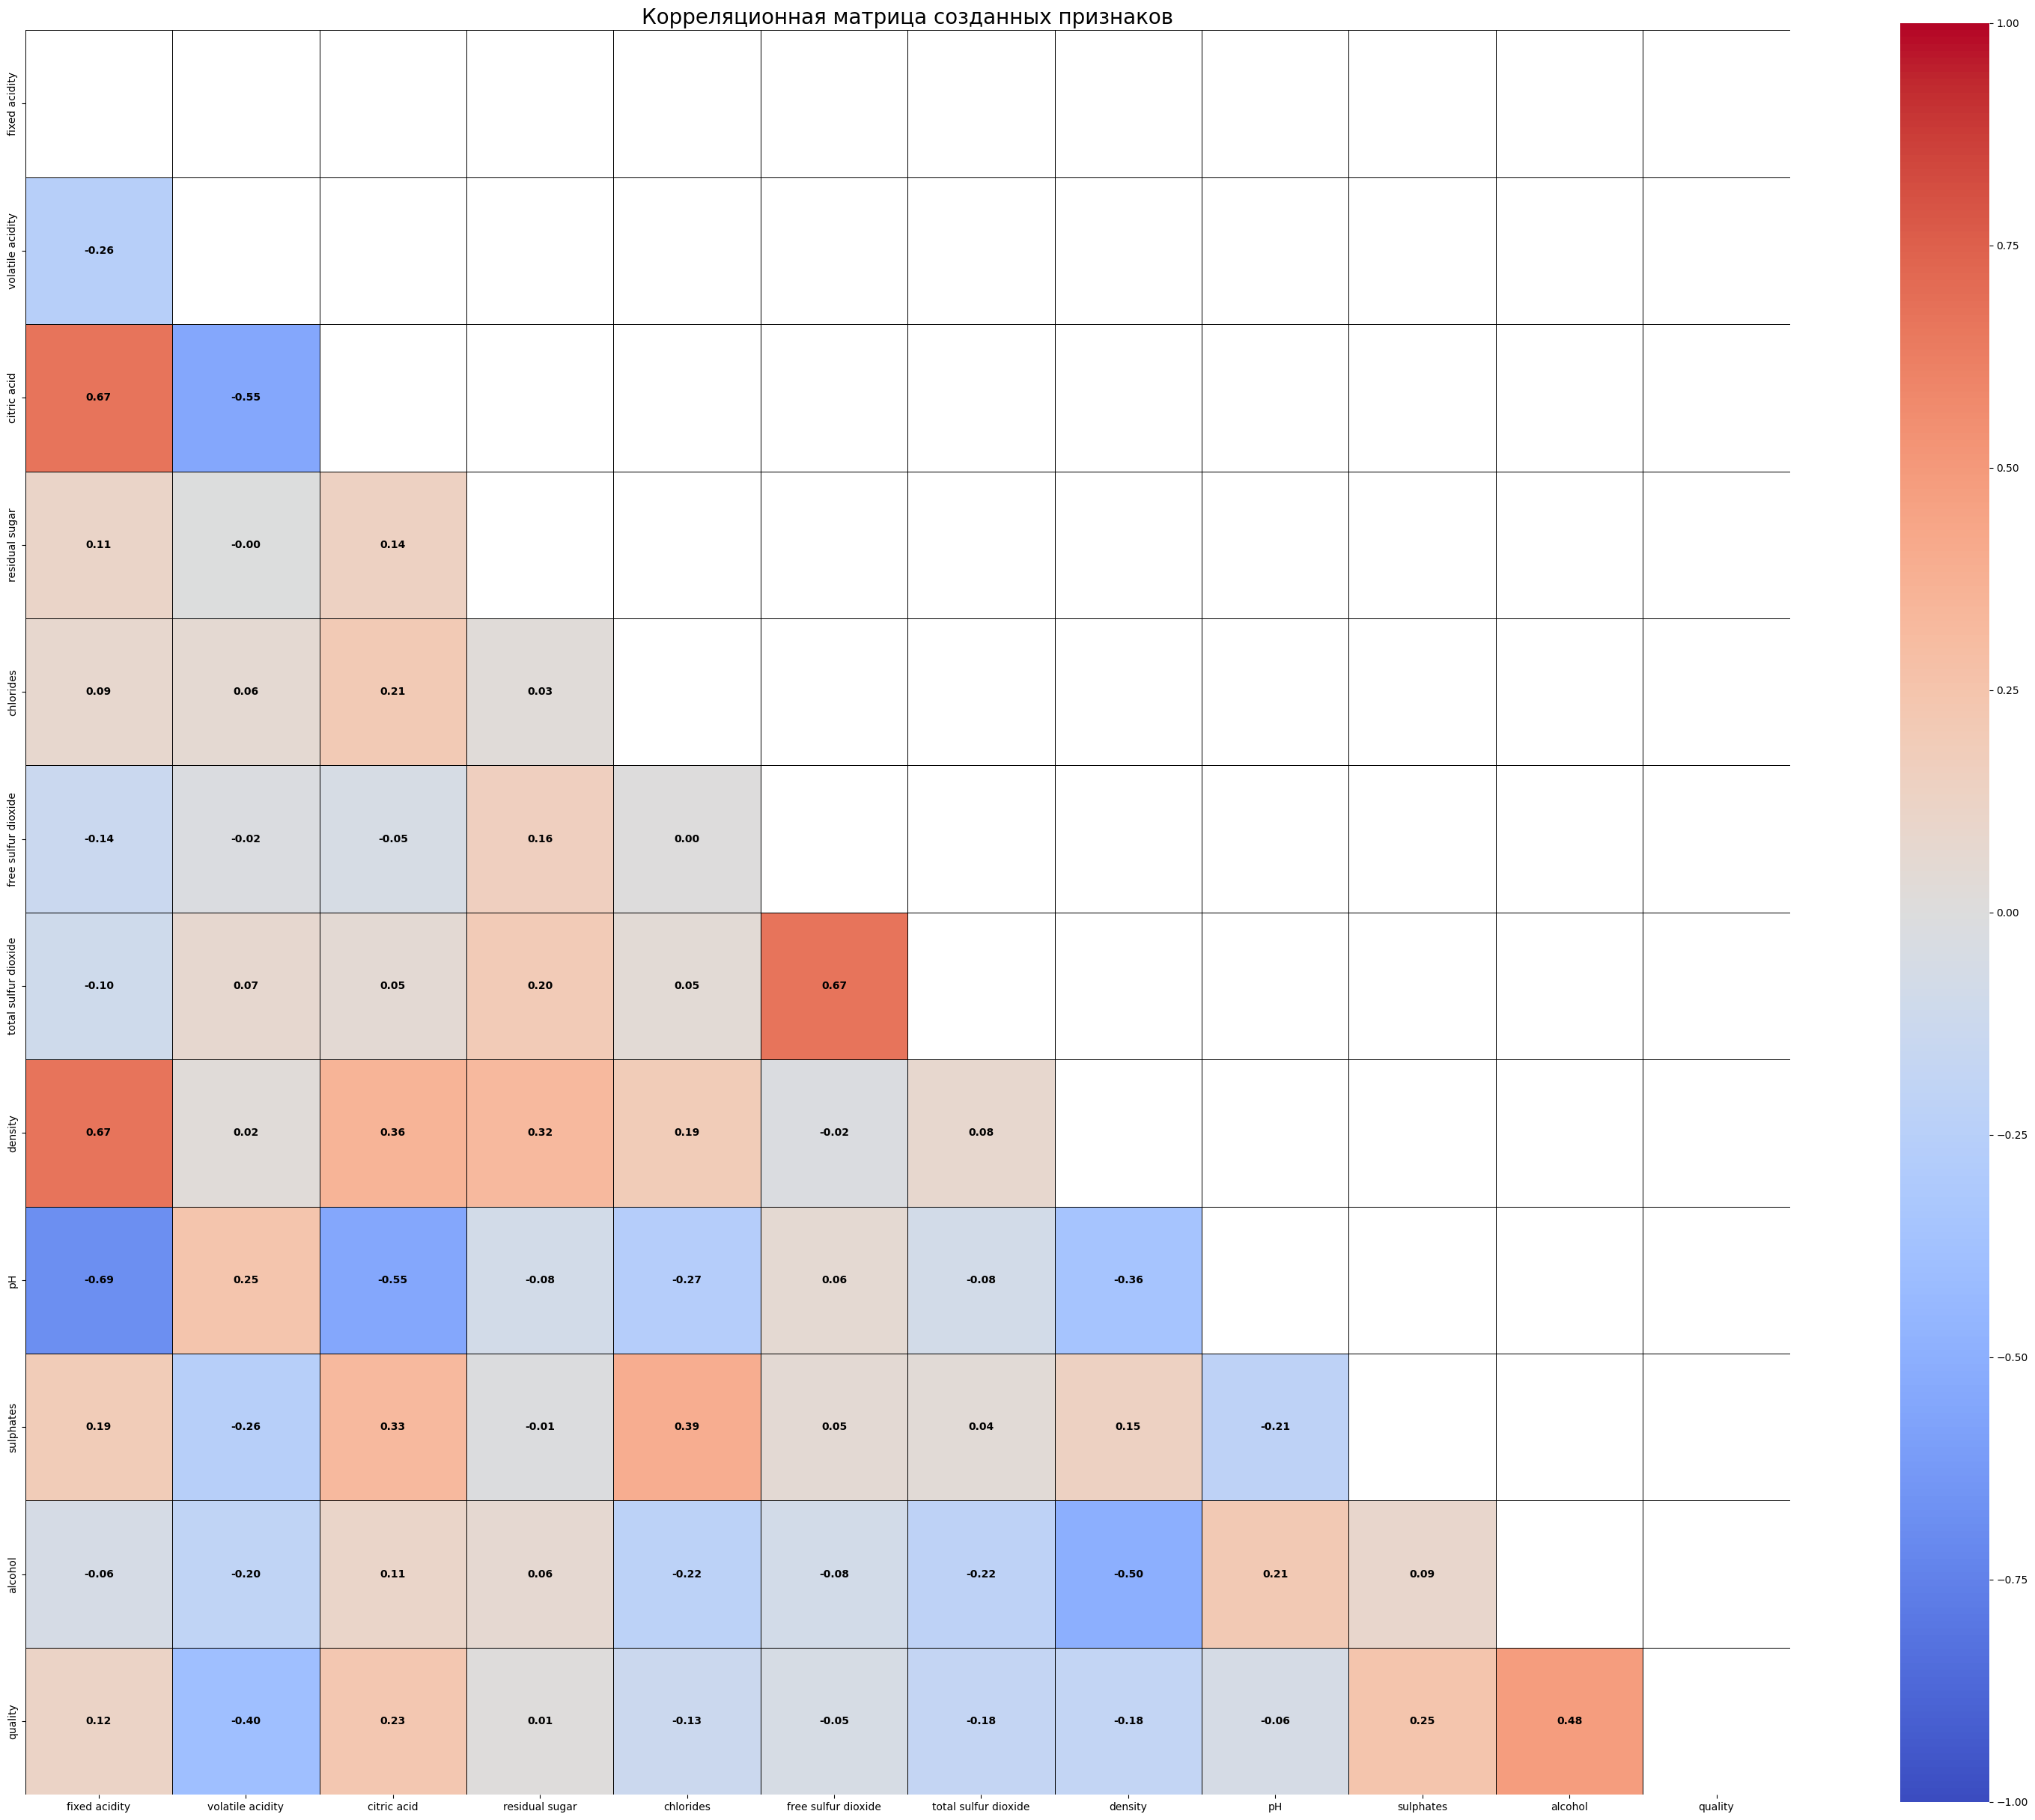

---------------------------------------------------------------------------------------------------------------------------


In [15]:
# Повторно построим тепловую карту
heatmap_corr(
    data = winequality_df,
    title = 'Корреляционная матрица созданных признаков',
    figsize = (30, 30),
    cmap = 'coolwarm'
)

**Вывод:**

Исходя из построенной тепловой карты максимальное значение корреляции не превышает $0.7$, что вполне допустимо, следовательно высококоррелированных связей небыло обнаружено.

#### $3.2$

#### **Распределение признаков.**

Проверим распределение всех признаков.

Для этого используем **тест Шапиро-Уилка** чтобы провести анализ распределения всех признаков:

In [16]:
# Задаём уровень значимости
alpha = 0.05



# Создаём цикл по всем признакам
for column in winequality_df.columns:
    
    # Выводим заголовок для текущей переменной
    print()
    print(f'\nТестирование нормальности распределения для "{column}":')
    print()
    
    # Выполняем тест Шапиро-Уилка
    stat, p_value = stats.shapiro(winequality_df[column].dropna())
    
    # Выводим результаты теста
    print(f'Статистика: {stat:.4f}, p-значение: {p_value:.4f}')
    
    # Проверяем гипотезу
    if p_value > alpha:
        print(f'Распределение признака "{column}" нормально (не отвергаем гипотезу H0)')
    else:
        print(f'Распределение признака "{column}" не нормально (отвергаем гипотезу H0)')
        
    print('-' * 80)
    print('\n')



Тестирование нормальности распределения для "fixed acidity":

Статистика: 0.9468, p-значение: 0.0000
Распределение признака "fixed acidity" не нормально (отвергаем гипотезу H0)
--------------------------------------------------------------------------------




Тестирование нормальности распределения для "volatile acidity":

Статистика: 0.9702, p-значение: 0.0000
Распределение признака "volatile acidity" не нормально (отвергаем гипотезу H0)
--------------------------------------------------------------------------------




Тестирование нормальности распределения для "citric acid":

Статистика: 0.9555, p-значение: 0.0000
Распределение признака "citric acid" не нормально (отвергаем гипотезу H0)
--------------------------------------------------------------------------------




Тестирование нормальности распределения для "residual sugar":

Статистика: 0.5767, p-значение: 0.0000
Распределение признака "residual sugar" не нормально (отвергаем гипотезу H0)
-------------------------------

Из полученных результатов можно заключить, что практически ни один признак не имеет нормального распределения. Теперь, для подтверждения результатов, визуализируем наше распределение.

Для этого создадим функцию для построения графика распределения признаков:

In [17]:
# Создаём функцию 'features_distribution_plot()' для построения графика распределения признаков
def features_distribution_plot(data, title = None, figsize = None):
    
    
    # Создаём заголовок для графика
    print('\nГрафик распределения признаков:')
    print('-' * 123)
    
    
    '''
    
    Функция для построения графиков распределения признаков.
    
    Параметры:
    - data: pandas DataFrame с данными.
    - features: список признаков для анализа.
    - title: заголовок графика.
    - figsize: размер графика.
    
    '''
    
    
    # Задаём размер графика
    fig, ax = plt.subplots(figsize = figsize)

    # Построение плотностей распределения
    for column in data.columns:
    
        sns.kdeplot(
            data[column], 
            label = column, 
            ax = ax
        )



    # Настройка легенды: выносим за пределы графика
    plt.legend(
        bbox_to_anchor = (1.05, 1),
        loc = 'upper left',
        fontsize = 10
    )

    # Настройка графика
    plt.title(title, fontsize = 20)
    plt.xlabel('Значение', fontsize = 15)
    plt.ylabel('Плотность', fontsize = 15)
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.tight_layout()  
    
    
    
    # Выводим график
    plt.show()
    print('-' * 123)

Построим график распределения признаков:


График распределения признаков:
---------------------------------------------------------------------------------------------------------------------------


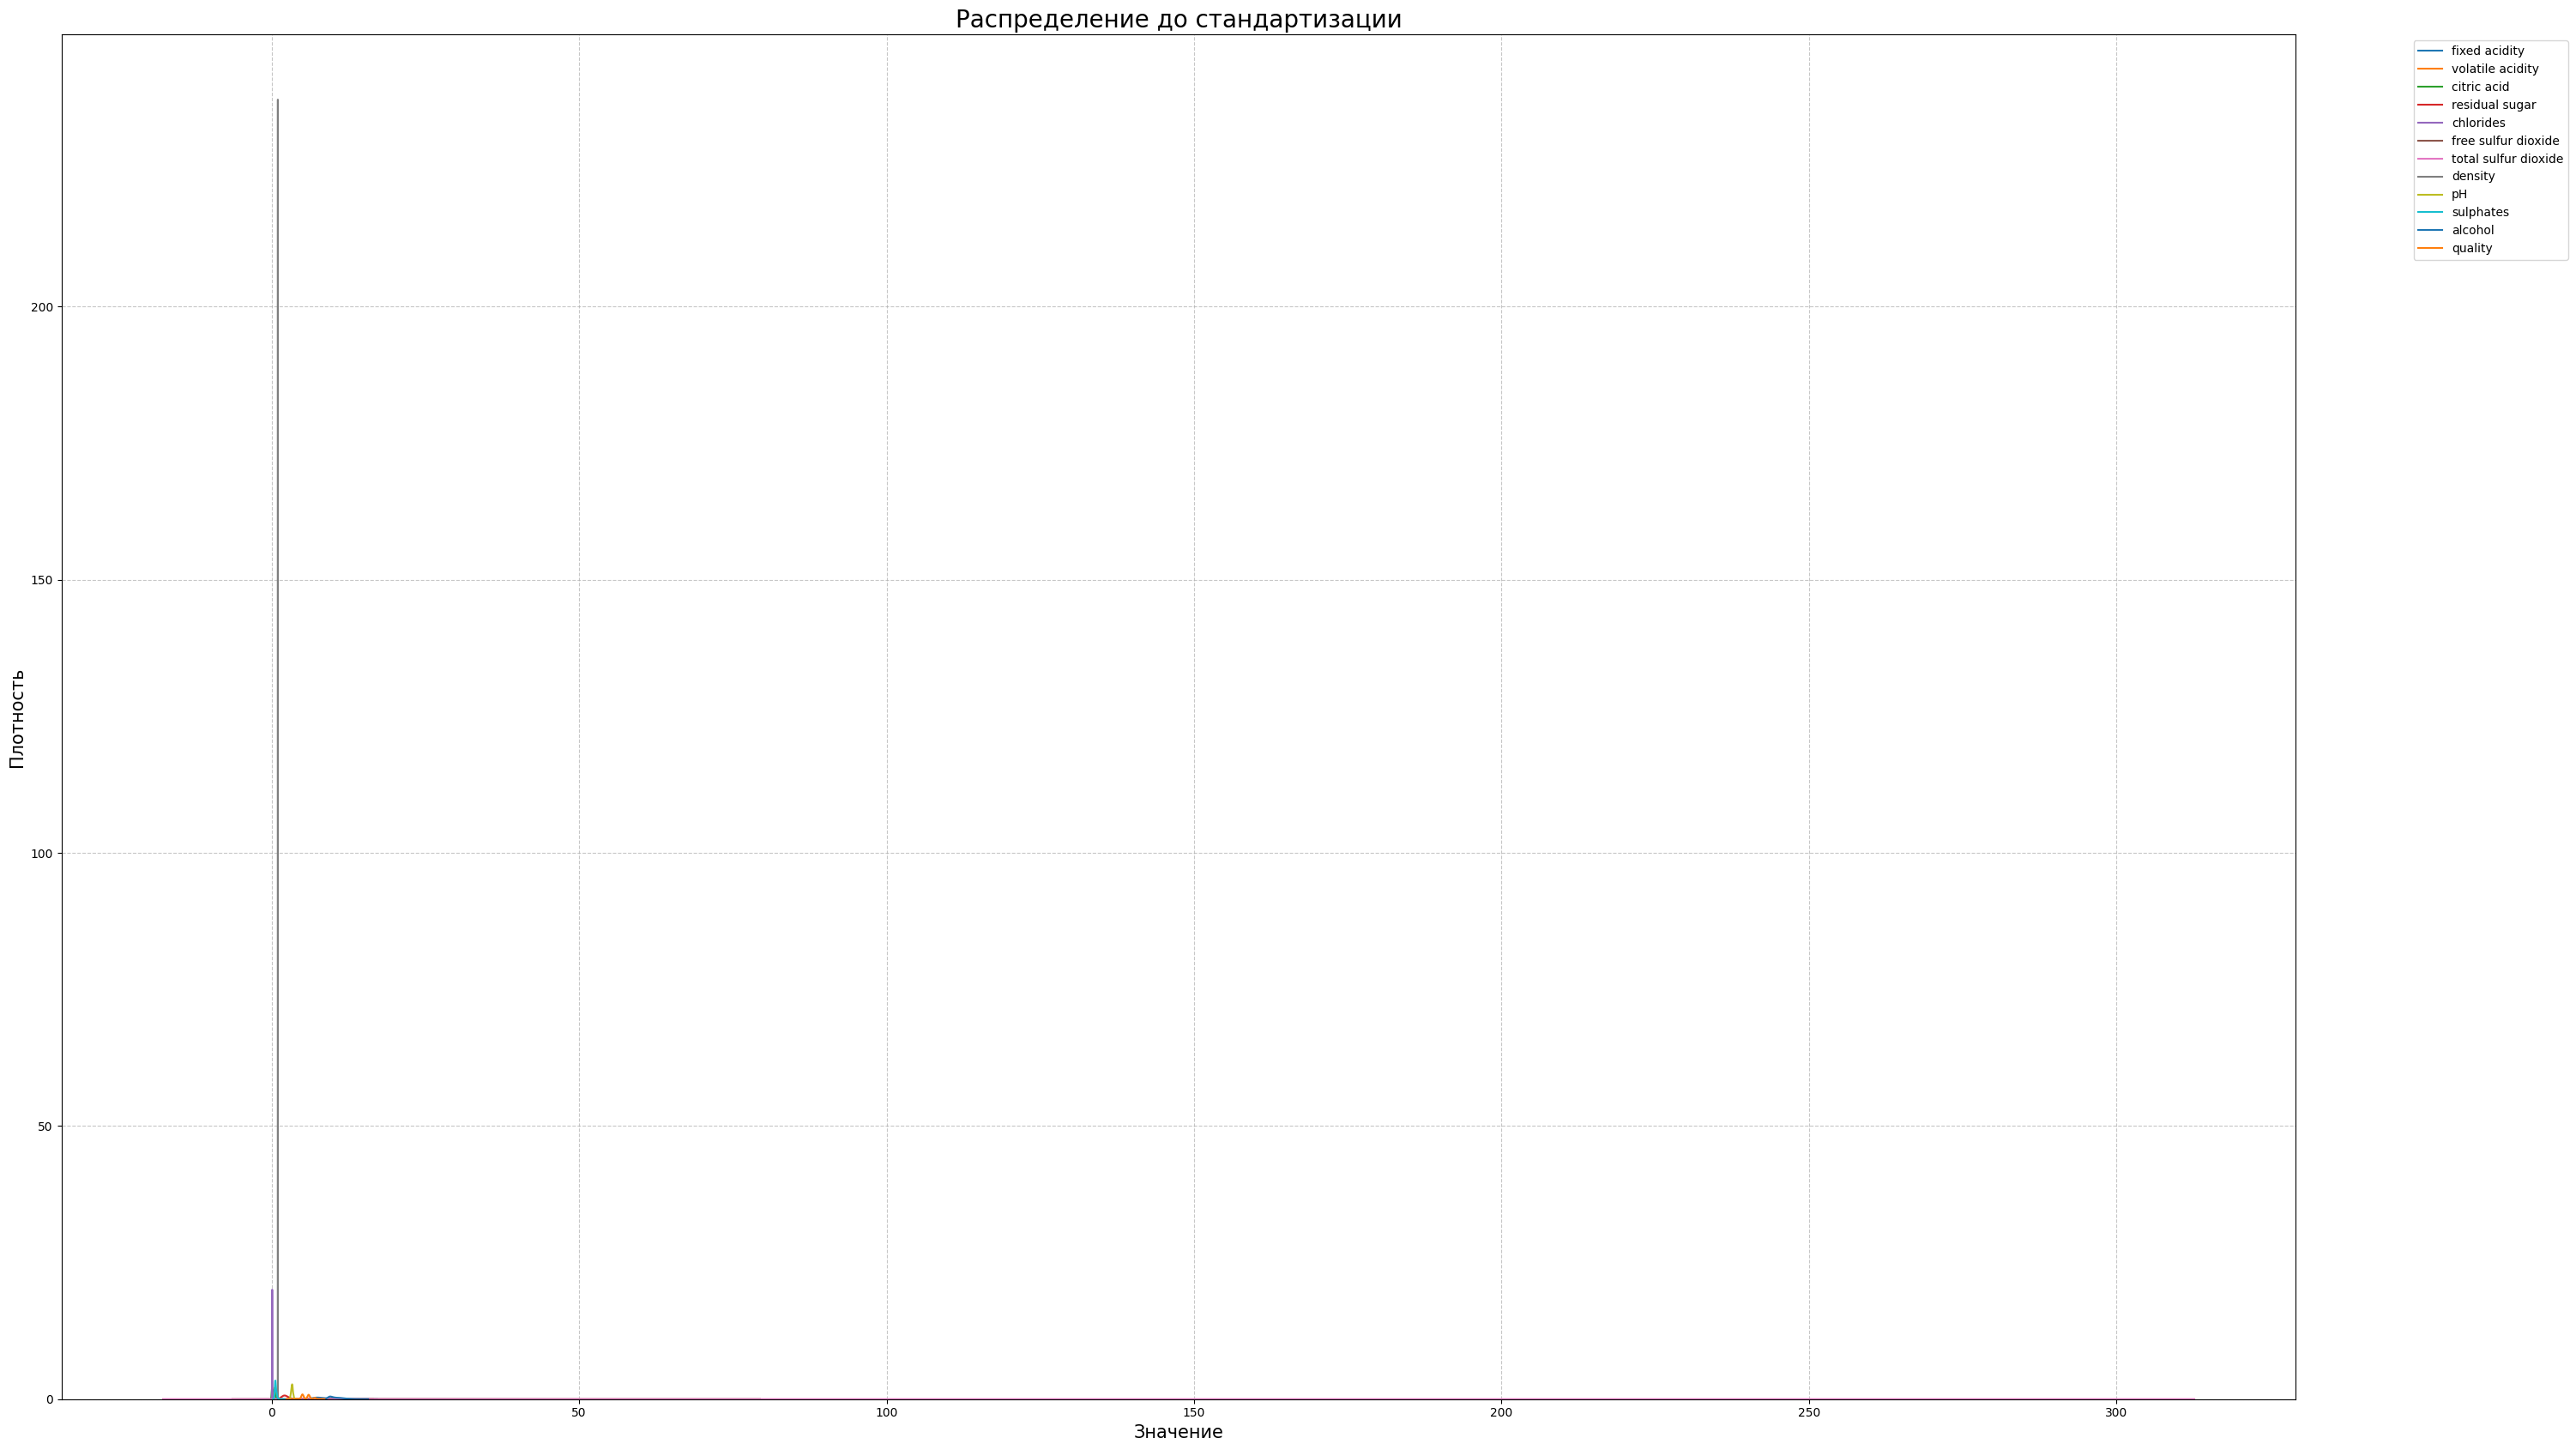

---------------------------------------------------------------------------------------------------------------------------


In [18]:
# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков
features_distribution_plot(
    data = winequality_df,
    title = 'Распределение до стандартизации',
    figsize = (30, 17)
)

**Вывод:**

По графику видно, что распределение имеет правостороннюю ассиметрию. Для более корректной работы модели необходимо провести преобразование признаков. Для этого можно воспользоваться методом `StandardScaler()`, который мы интегрируем в `pipeline`.

=============================================================================================================================================

## <CENTER> **`4.` Feature engineering (Создание новых признаков)**

На данном этапе преобразуем некоторые из признаков.

#### $4.1$

Преобразуем признак `quality` в категориальный:

In [19]:
# Если значение меньше 6.5, выведем 'bad wine'; в противном случае - 'good wine'
# при этом, во избежании утечки данных, занесём обновлённый признак в отдельную переменную
y = winequality_df['quality'].apply(lambda x: 'bad wine' if x < 6.5 else 'good wine')


# Выведем результат
print('\nУникальные значения переменной "y":\n\n{}'.format(y.value_counts()))
print('-' * 25)


Уникальные значения переменной "y":

quality
bad wine     1175
good wine     184
Name: count, dtype: int64
-------------------------


Создадим функцию для построения графика распределения целевого признака:

In [20]:
# Создаём функцию для построения графика распределения целевой переменной
def target_distribution_plot(target, title, color, figsize = (30, 15)):
    
    
    '''
    
    Функция для построения графика распределения целевой переменной.
    
    Параметры:
    - target: pandas Series с данными,
    - title: заголовок графика,
    - color: цветовая палитра,
    - figsize: размер графика.
    
    '''
    
    
    # Создаём заголовок для графика
    print(f'\n{title}')
    print('-' * 123)
    
    
    # Задаём размер графика
    fig, ax = plt.subplots(1, 2, figsize = figsize)
    
    # Гистограмма
    sns.countplot(
        x = target,
        ax = ax[0],
        palette = color,
        hue = target,
        order = target.value_counts().index,
        edgecolor = 'black',
        linewidth = 1.5
    )
     
    # Настройка графика
    ax[0].set_xticklabels(
        target.value_counts().index, 
        fontsize = 15
    )
    
    ax[0].bar_label(ax[0].containers[0], padding = 3, fontsize = 12)
    ax[0].set_title('Распределение целевой переменной', fontsize = 20)
    ax[0].set_xlabel('Класс', fontsize = 15)
    ax[0].set_ylabel('Количество', fontsize = 15)
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.tight_layout()



    # Кольцевая диаграмма
    target_counts = target.value_counts()

    wedges, texts, autotexts = ax[1].pie(
        target_counts,
        labels = target_counts.index,
        colors = sns.color_palette(color, 3),
        autopct = '%1.1f%%',
        startangle = 90
    )
    
    centre_circle = plt.Circle((0, 0), 0.70, fc = 'white')
    fig.gca().add_artist(centre_circle)
    ax[1].set_title('Распределение целевой переменной', fontsize = 20)



    # Выводим график
    plt.show()
    print('-' * 123)

Построим график распределения целевого признака:


Стобчатая и круговая диаграммы распределения целевой переменной:
---------------------------------------------------------------------------------------------------------------------------


/var/folders/9z/th6zqsk53cbb_rkn6zr5cgzh0000gn/T/ipykernel_4019/3524510739.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(


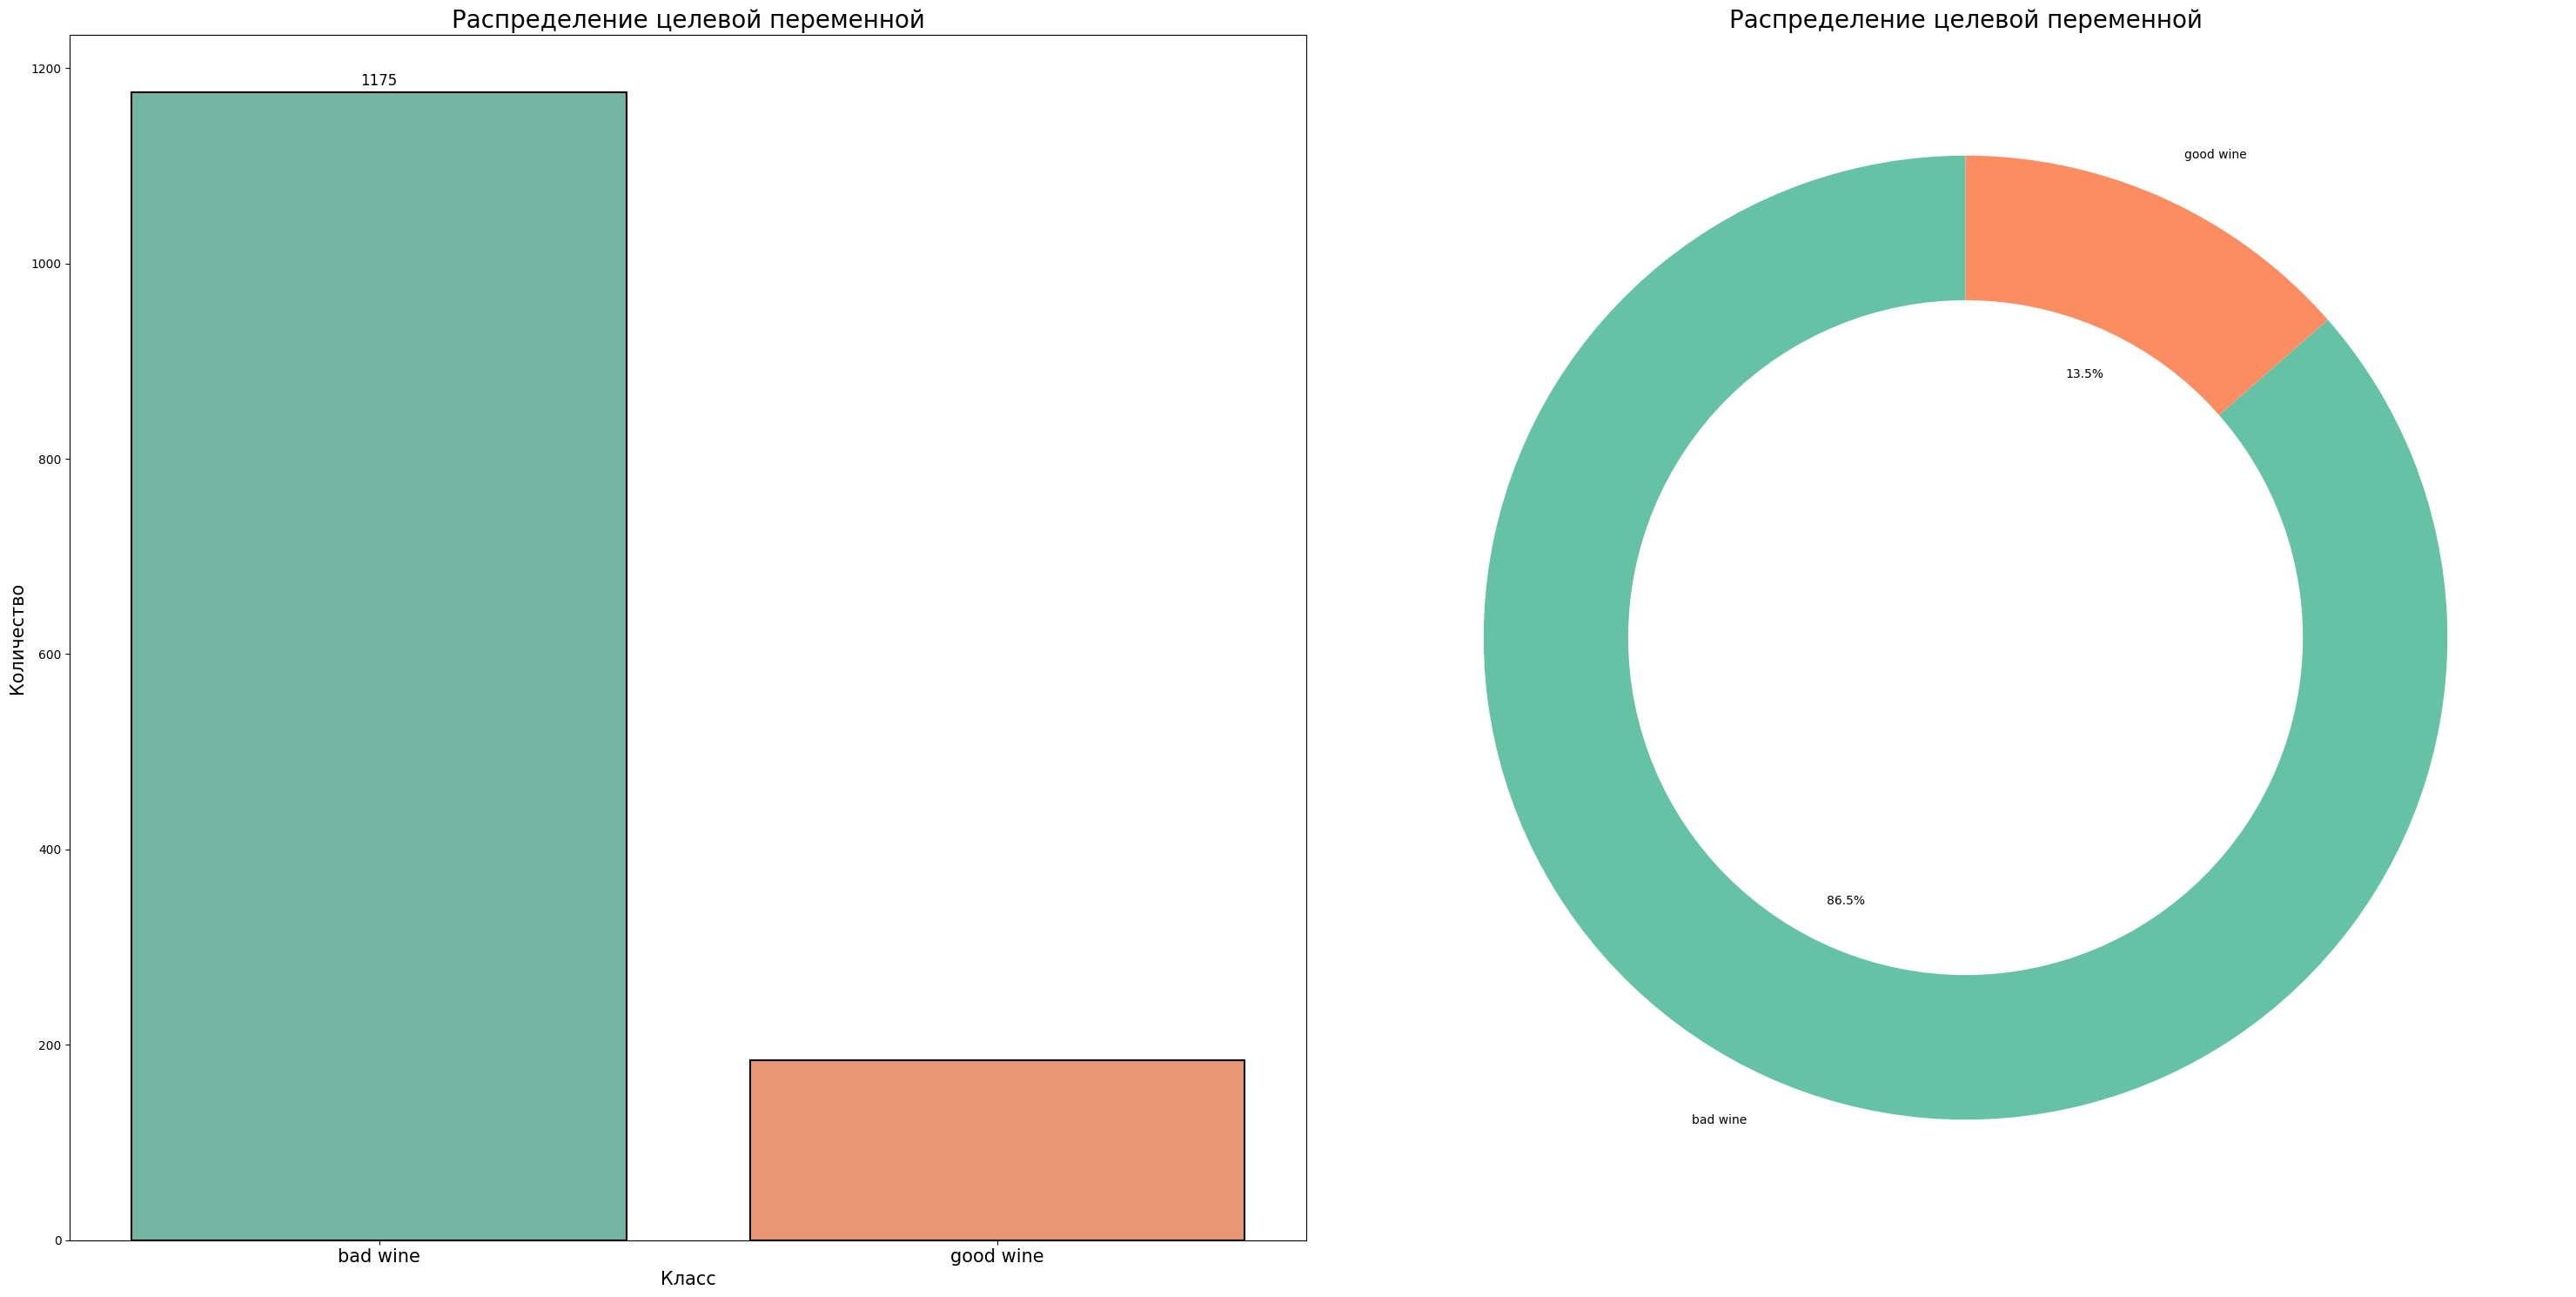

---------------------------------------------------------------------------------------------------------------------------


In [21]:
# Применяем функцию 'target_distribution_plot()' для построения графика распределения целевой переменной
target_distribution_plot(
    target = y,
    color = 'Set2',
    title = 'Стобчатая и круговая диаграммы распределения целевой переменной:'
)

**Вывод**:

По полученному графику видно, что среди поставленных оценок наибольшее количество - негативные, что сведетельствует о низком качестве наибольшего количества продукта. Тем самым наблюдается явный дисбаланс классов, что требует балансировки перед подачей в модель.

Закодируем целевую переменную:

In [22]:
# Создаём объект класса 'LabelEncoder'           
L_encoder = preprocessing.LabelEncoder()

# Делаем преобразование, при этом обновлённый признак занесём в новую переменную
y_encoded = L_encoder.fit_transform(y)

#### $4.2$

Создадим следующие признаки:

- Баланс «летучести» кислоты;
- Доля свободного $SO₂$ – показатель свежести и микробиологической стабильности;
- Признак, показывающий насколько сладость «маскируется» крепостью;
- Признак, учитывающий, что высокая плотность часто вызвана сахаром, а алкоголь, наоборот, снижает плотность.

Обернём всё в одну функцию:

In [23]:
# Создаём функцию 'make_ratios' для создания новых признаков
def make_ratios(data):
    
    # Создаём копию данных
    data = data.copy()
    
    # Создаём признаки
    data['volatile/fixed']      = data['volatile acidity'] / data['fixed acidity']
    data['free/total_SO2']      = data['free sulfur dioxide'] / data['total sulfur dioxide']
    data['sugar/alcohol']       = data['residual sugar'] / data['alcohol']
    data['chlorides/density']   = data['chlorides'] / data['density']
    data['sulphates/total_SO2'] = data['sulphates'] / data['total sulfur dioxide']
    data['total_acidity']       = data[['fixed acidity','volatile acidity','citric acid']].sum(axis = 1)
    data['acid_sugar_ratio']    = data['total_acidity'] / (data['residual sugar'] + 1e-6)
    data['corr_density']        = data['density'] - 0.003 * data['alcohol']
    data['strong_acids_idx']    = data['pH'] * data['total_acidity']
    data['buffer_idx']          = data['pH'] / (data['citric acid'] + 1e-6)
    
    # Возвращаем результат
    return data




# Теперь обернём нашуфункцию в трансформер, чтобы в дальнейшем использовать её в pipeline
ratio_ft = preprocessing.FunctionTransformer(func = make_ratios).set_output(transform = 'pandas')

#### $4.3$

Создаём `pipeline` для препроцессинга:

In [24]:
# Создаём 'pipeline' для создания и преобразования признаков
numeric_pipe = pipeline.Pipeline(
    steps = [
        ('ratio', ratio_ft),
        ('yeo', preprocessing.PowerTransformer(method = 'yeo-johnson')),
        
        ('poly', preprocessing.PolynomialFeatures(
            degree = 2,
            include_bias = False,
            interaction_only = False
        )),
        
        ('scaler', preprocessing.StandardScaler())
    ]
)




# Создаём список базовых признаков
base_features = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH',
    'sulphates', 'alcohol'
]

# Создаём 'pipeline' который применяет разные пайплайны к разным колонкам
preprocess_pipe = compose.ColumnTransformer(
    [('num', numeric_pipe, base_features)],
    remainder = 'drop'
)

=============================================================================================================================================

## <CENTER> **`5.` Machine Learning**

На данном этапе обучим модель `SVM`.

**Определение метрик.**

Используем следующие метрики для оценки:

* **Accuracy**:________________(метрика точности),

* **Precision**:_______________(положительное прогнозное значение),

* **Recall**:__________________(доля истинно положительных результатов),

* **F1-score**:________________(среднее значение Точности измерений),

* **Classification report**:___(таблица рассчитанных метрик).

Создадим функцию для вычисления метрик:

In [25]:
# Создаём функцию 'print_metrics'       
def print_metrics(y_true, y_predict, model_name, decimal_places = 3):
    
    '''
    
    Вычисляет и выводит метрики (Accuracy, Precision, Recall, F1-score, Classification report) для оценки модели.
    
    Параметры:
    - y_true: истинные значения (например, y_valid)
    - y_pred: предсказанные значения (например, y_log_predict)
    - model_name: строка с названием модели (например, "LogisticRegression")
    - decimal_places: количество знаков после запятой для форматирования (по умолчанию 3)
    
    '''
    
    
    # Вычисляем метрики
    accuracy_metric = metrics.accuracy_score(y_true, y_predict)
    precision_metric = metrics.precision_score(y_true, y_predict, average = 'weighted')
    recall_metric = metrics.recall_score(y_true, y_predict, average = 'weighted')
    f1_metric = metrics.f1_score(y_true, y_predict, average = 'weighted')
    cr_metrics = metrics.classification_report(y_true, y_predict)
    
    
    # Выведем результат
    print(f'\n{model_name} (значения метрик):\n')
    print(f'Accuracy: {accuracy_metric:.{decimal_places}f}')
    print('-' * 80)
    print(f'Precision: {precision_metric:.{decimal_places}f}')
    print('-' * 80)
    print(f'Recall: {recall_metric:.{decimal_places}f}')
    print('-' * 80)
    print(f'F1-score: {f1_metric:.{decimal_places}f}')
    print('-' * 80)
    print()
    print(f'Classification report:\n\n{cr_metrics}')
    print('-' * 80)

#### $5.1$

Разделим данные на тренировочную и тестовую выборки:

In [26]:
# Создадим матрицу наблюдений 'X'           
X = winequality_df.drop(columns = 'quality')

# Разделим данные с использование стратифицированного разбиения
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y_encoded,
    test_size = 0.2,
    stratify = y_encoded,
    random_state = 42
)




# Выведем информацию по тренировочной выборке
check_data_inf(
    data = X_train,
    data_name = 'X_train',
    length1 = 40,
    length2 = 123
)
print('\n\n')

# Выведем информацию по тестовой выборке
check_data_inf(
    data = X_test,
    data_name = 'X_test',
    length1 = 40,
    length2 = 123
)


Данные таблицы "X_train" имеют следующую размерность:

Количество строк: 1087;
Количество признаков (столбцов): 11.
----------------------------------------


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
534,10.0,0.48,0.24,2.7,0.102,13.0,32.0,1.00000,3.28,0.56,10.0
1090,10.0,0.26,0.54,1.9,0.083,42.0,74.0,0.99451,2.98,0.63,11.8
219,7.8,0.53,0.33,2.4,0.080,24.0,144.0,0.99655,3.30,0.60,9.5
653,9.4,0.33,0.59,2.8,0.079,9.0,30.0,0.99760,3.12,0.54,12.0
527,7.0,0.38,0.49,2.5,0.097,33.0,85.0,0.99620,3.39,0.77,11.4
...,...,...,...,...,...,...,...,...,...,...,...
116,8.3,0.54,0.28,1.9,0.077,11.0,40.0,0.99780,3.39,0.61,10.0
1332,8.4,0.39,0.10,1.7,0.075,6.0,25.0,0.99581,3.09,0.43,9.7
1242,9.0,0.40,0.41,2.0,0.058,15.0,40.0,0.99414,3.22,0.60,12.2
59,7.3,0.39,0.31,2.4,0.074,9.0,46.0,0.99620,3.41,0.54,9.4


---------------------------------------------------------------------------------------------------------------------------




Данные таблицы "X_test" имеют следующую размерность:

Количество строк: 272;
Количество признаков (столбцов): 11.
----------------------------------------


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1312,8.0,1.18,0.21,1.9,0.083,14.0,41.0,0.99532,3.34,0.47,10.5
546,7.5,0.55,0.24,2.0,0.078,10.0,28.0,0.99830,3.45,0.78,9.5
890,7.2,0.34,0.24,2.0,0.071,30.0,52.0,0.99576,3.44,0.58,10.1
1350,9.0,0.60,0.29,2.0,0.069,32.0,73.0,0.99654,3.34,0.57,10.0
719,7.1,0.66,0.00,3.9,0.086,17.0,45.0,0.99760,3.46,0.54,9.5
...,...,...,...,...,...,...,...,...,...,...,...
1386,7.4,0.64,0.07,1.8,0.100,8.0,23.0,0.99610,3.30,0.58,9.6
631,10.4,0.28,0.54,2.7,0.105,5.0,19.0,0.99880,3.25,0.63,9.5
1111,5.4,0.42,0.27,2.0,0.092,23.0,55.0,0.99471,3.78,0.64,12.3
615,9.6,0.60,0.50,2.3,0.079,28.0,71.0,0.99970,3.50,0.57,9.7


---------------------------------------------------------------------------------------------------------------------------


#### $5.2$

Подготовим данные к подаче в модель:

In [27]:
# Создаём имбелёр-пайплайн
final_pipeline = pipeline.Pipeline(
    
    steps = [
        ('preprocess', preprocess_pipe),
        
        ('smote',      over_sampling.SMOTE(
            sampling_strategy = 0.8, 
            random_state = 42
        )),
        
        ('SVM_model',  svm.SVC(
            class_weight = {0:1, 1:4}, 
            probability = False
        ))
        
    ]
    
).set_output(transform = 'pandas')



# Задаём сетку гиперпараметров
param_grid = {
    'SVM_model__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'SVM_model__C':      [0.3, 1, 3, 10],
    'SVM_model__gamma':  [0.001, 0.01, 0.03, 0.1],
    'SVM_model__degree': [2, 3]
}



# Задаём параметр кросс-валидации
cv = model_selection.StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

Обучаем модель `GridSearchCV`:

In [28]:
# Производим поиск параметров по сетке
grid_search = model_selection.GridSearchCV(
    estimator = final_pipeline,
    param_grid = param_grid,
    cv = cv,
    scoring = 'average_precision',
    n_jobs = -1,
    verbose = 2
)

# Обучаем модель 
grid_search.fit(X_train, y_train)

# Сохраняем лучшую модель
best_model = grid_search.best_estimator_

# Делаем предсказание для тестовой выборки
y_predict = best_model.predict(X_test)

# Сохраним полученные гиперпараметры в переменной
best_parameters = grid_search.best_params_



# Выведем наилучшие значения гиперпараметров
print(f'\nНаилучшие значения гиперпараметров: {best_parameters}')
print('-' * 123)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=rbf; total time=   0.3s
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=rbf; total time=   0.4s
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=linear; total time=   0.4s
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=rbf; total time=   0.4s
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=linear; total time=   0.5s
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=linear; total time=   0.5s
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=linear; total time=   0.5s
[CV] END SVM_model__C=0.3, SVM_model__degree=2, SVM_model__gamma=0.001, SVM_model__kernel=linear; total time=   0.7s
[CV] END S

Считаем метрики:

In [29]:
# Применяем функцию 'print_metrics' для рассчёта метрик
print_metrics(
    y_true = y_test,
    y_predict = y_predict,
    model_name = '"SVM" with "GridSearchCV"'
)


"SVM" with "GridSearchCV" (значения метрик):

Accuracy: 0.860
--------------------------------------------------------------------------------
Precision: 0.833
--------------------------------------------------------------------------------
Recall: 0.860
--------------------------------------------------------------------------------
F1-score: 0.840
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       235
           1       0.47      0.24      0.32        37

    accuracy                           0.86       272
   macro avg       0.68      0.60      0.62       272
weighted avg       0.83      0.86      0.84       272

--------------------------------------------------------------------------------


Построим `ConfusionMatrix`:


ConfusionMatrix:
---------------------------------------------------------------------------

TEST accuracy: 0.8603


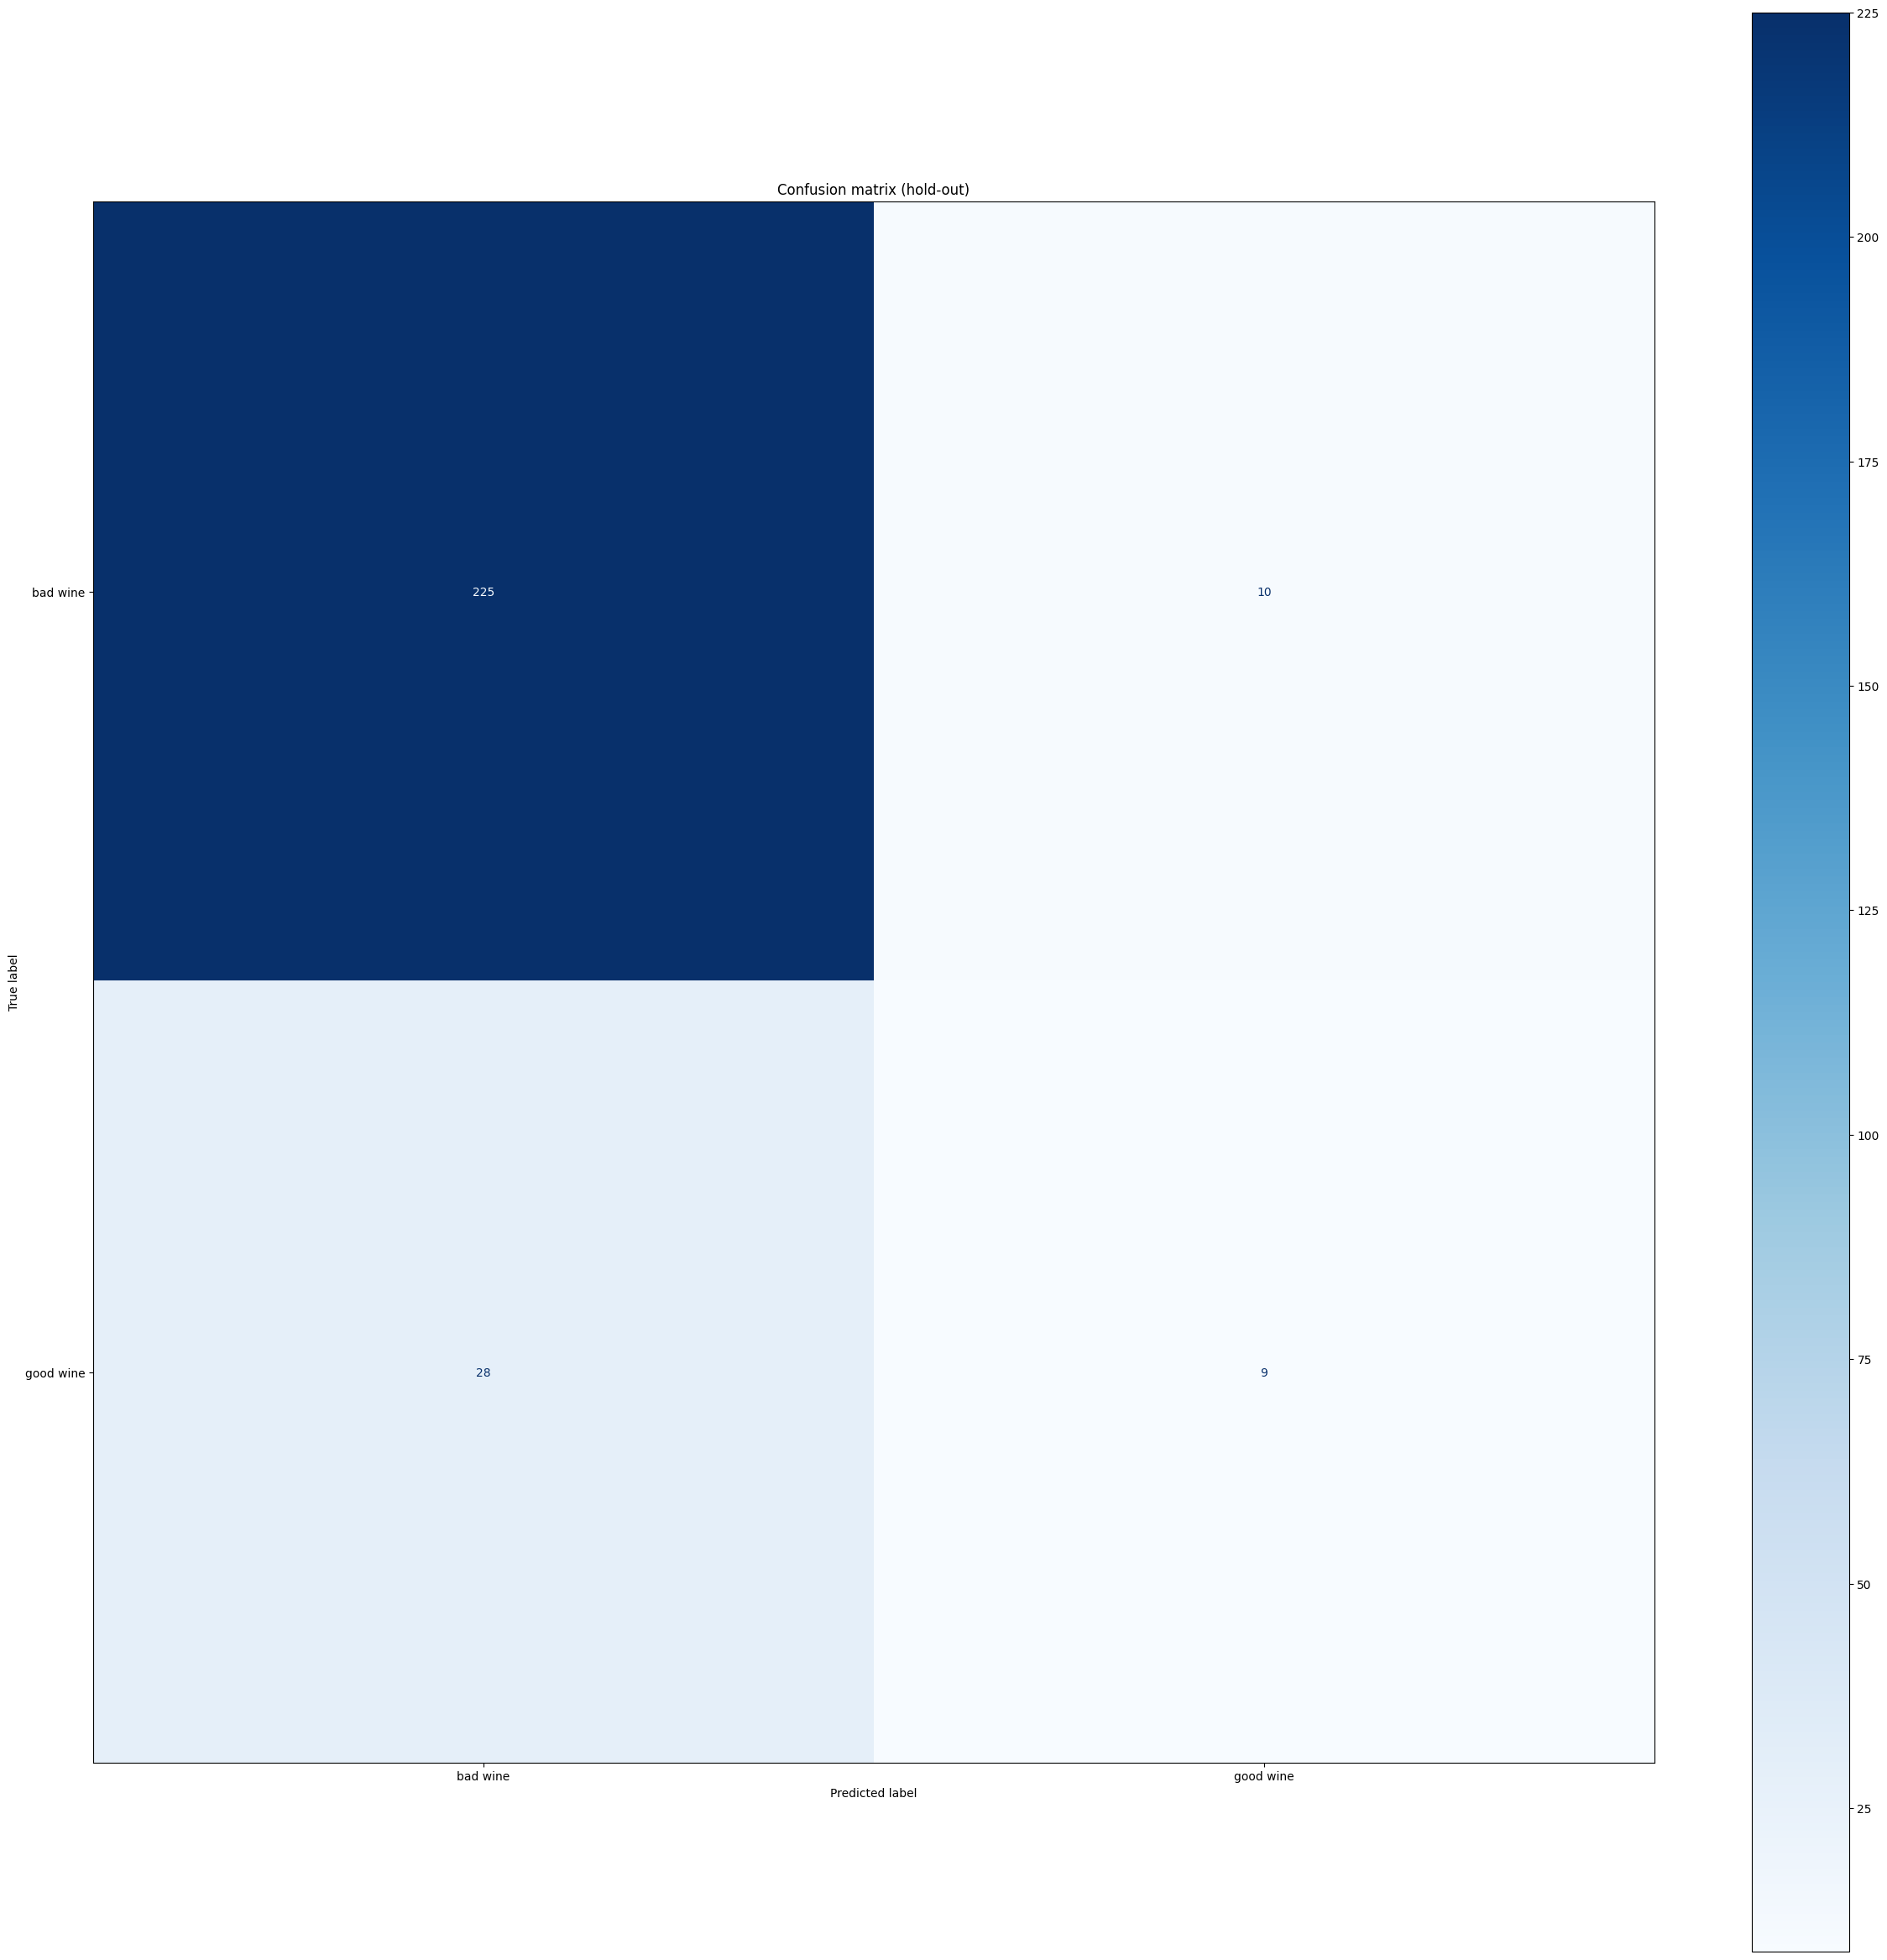

---------------------------------------------------------------------------


In [30]:
# Отдельно рассчитаем метрики accuracy и confusion_matrix
acc = metrics.accuracy_score(y_test, y_predict)
cm = metrics.confusion_matrix(y_test, y_predict, labels = [0, 1])



# Задаём заглавие для графика
print('\nConfusionMatrix:')
print('-' * 75)

# Выводим метику 'accuracy', рассчитанную на тестовой выборке
print(f'\nTEST accuracy: {acc:.4f}')

# Строим 'ConfusionMatrix'
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = L_encoder.inverse_transform([0, 1])
)

disp.plot(cmap = 'Blues', values_format = 'd')
plt.title('Confusion matrix (hold-out)');

# Выводим матрицу
plt.show()
print('-' * 75)

Теперь визуализируем графики кривых `ROC` и `PR`:


Кривые рассчитанных метрик "ROC" и "PR":
---------------------------------------------------------------------------------------------------------------------------


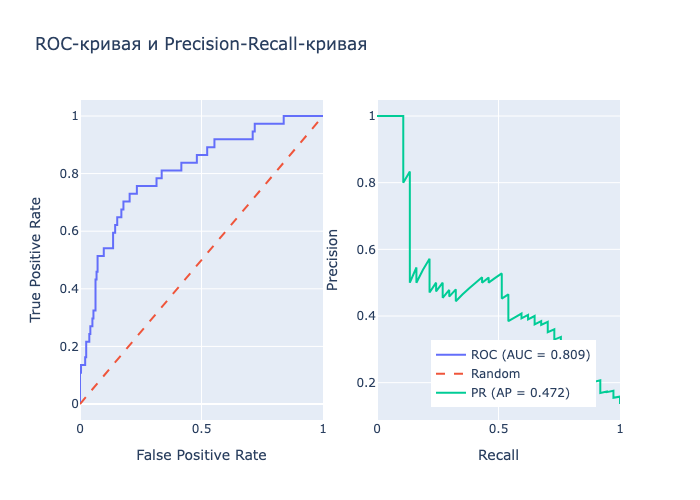

---------------------------------------------------------------------------------------------------------------------------


In [31]:
# Задаём заглавие для графика
print('\nКривые рассчитанных метрик "ROC" и "PR":')
print('-' * 123)

# Сохраним метрики модели для каждого объекта test-набора в отдельную переменную
scores = best_model.decision_function(X_test)

# Рассчитываем 'ROC'         
fpr, tpr, _ = metrics.roc_curve(y_test, scores, pos_label=1)
roc_auc     = metrics.auc(fpr, tpr)

# Рассчитываем 'Precision-Recall'
prec, rec, _ = metrics.precision_recall_curve(y_test, scores, pos_label=1)
pr_auc       = metrics.average_precision_score(y_test, scores, pos_label=1)





# Рисуем две кривые одним полотном 
fig = go.Figure()

# Рисуем кривую 'ROC'
fig.add_trace(
    go.Scatter(
        x = fpr, 
        y = tpr, 
        mode = 'lines',
        name = f'ROC (AUC = {roc_auc:.3f})'
    )
)

fig.add_trace(
    
    go.Scatter(
        x = [0, 1], 
        y = [0, 1], 
        mode = 'lines', 
        name = 'Random', 
        line = dict(dash = 'dash')
    )
    
)


# Рисуем кривую 'PR'
fig.add_trace(
    
    go.Scatter(
        x = rec, 
        y = prec, 
        mode = 'lines',
        name = f'PR (AP = {pr_auc:.3f})',
        xaxis = 'x2', 
        yaxis = 'y2'   
    )
    
)


# Оформляем две оси
fig.update_layout(
    title = 'ROC-кривая и Precision-Recall-кривая',
    height = 600,
    width = 1200,
    legend = dict(x = 0.65, y = 0.04),
    
    # Левая панель (ROC)
    xaxis = dict(domain = [0, 0.45], title = 'False Positive Rate'),
    yaxis = dict(title = 'True Positive Rate'),
    
    # Правая панель (PR)
    xaxis2 = dict(domain = [0.55, 1], title = 'Recall'),
    yaxis2 = dict(anchor = 'x2', title = 'Precision')
)



# Выводим график
fig.show('png')
print('-' * 123)

Сохраняем модель:

In [32]:
# Сохранение лучшей модели после GridSearchCV
joblib.dump(best_model, 'svm_pipeline_model.pkl')
print('\nBest model saved as svm_pipeline_model.pkl')
print('-' * 45)


Best model saved as svm_pipeline_model.pkl
---------------------------------------------


**Вывод:**

Модель успешно классифицирует «обычные» вина, но неустойчива при обнаружении «качественных», причиной чего может быть не очень подходящая модель `SVM`.

Требуется дальнейшая работа над балансировкой и, возможно, выбор альтернативных моделей, более устойчивых к редким классам (например, `Random Forest`, `XGBoost` или `Logistic Regression` с `class_weight`).

=============================================================================================================================================

## <CENTER> **`6.` Мониторинг модели**

На данном этапе проведём скраппинг метрик модели с помощью `Prometheus`.

#### $6.1$

##### **Скраппинг метрик.**

Для начала инициализируем метрики при помощи *Prometheus*:

In [33]:
# Инициализация метрик Prometheus
model_precision = Gauge('model_precision', 'Precision of the SVM model')
model_recall = Gauge('model_recall', 'Recall of the SVM model')
model_f1 = Gauge('model_f1', 'F1-score of the SVM model')
prediction_time = Gauge('model_prediction_time_seconds', 'Time taken for model prediction in seconds')
prediction_count = Counter('model_prediction_count', 'Total number of predictions made')

Теперь создадим функцию для обновления метрик на основе предсказаний модели:

In [34]:
# Создаём функцию 'update_metrics' для обновления метрик
def update_metrics(y_true, y_predict, inference_time):
    
    '''  
    
    Обновление метрик на основе предсказаний модели.
    
    Параметры:
      - y_true:           истинные значения целевой переменной,
      - y_predict:        предсказанные значения,
      - inference_time:   время обработки.
      
    '''
    
    # Рассчитываем метрики 'precission', 'recall' и 'f1'
    precision_metric = metrics.precision_score(y_true, y_predict, average = 'weighted')
    recall_metric = metrics.recall_score(y_true, y_predict, average = 'weighted')
    f1_metric = metrics.f1_score(y_true, y_predict, average = 'weighted')
    
    # Обновляем значения метрик
    model_precision.set(precision_metric)
    model_recall.set(recall_metric)
    model_f1.set(f1_metric)
    prediction_time.set(inference_time)
    
    # Увеличиваем счётчик предсказаний
    prediction_count.inc()

Создадим функцию для обновления метрик и выполнения предсказаний:

In [35]:
# Создаём функцию 'make_predictions'
def make_predictions(model, X_test, y_test):
    
    '''
    
    Функция для выполнения предсказаний и обновления метрик.
    
    Параметры:
      - model:  модель,
      - X_test: тестовая выборка,
      - y_test: целевая переменная.
      
    '''
    
    # Делаем предсказание и фиксируем время
    start_time = time.time()
    y_predict = model.predict(X_test)
    inference_time = time.time() - start_time
    
    # Обновляем метрики
    update_metrics(y_test, y_predict, inference_time)
    
    # Выводим результат
    return y_predict

Создадим функцию, которая загружает модель и переобучает её на новых данных, применяя весь пайплайн:

In [36]:
# Создаём функцию 'retrain_pipeline'
def retrain_pipeline(new_X, new_y, model_path = 'svm_pipeline_model.pkl'):
    
    
    # Загрузка существующей модели
    pipeline = joblib.load(model_path)
    
    
    # Объединяем старые данные с новыми
    # Предполагаем, что X_train и y_train доступны глобально
    if 'X_train' in globals() and 'y_train' in globals():
        X_combined = np.vstack((X_train, new_X))
        y_combined = np.concatenate((y_train, new_y))
    else:
        X_combined = new_X
        y_combined = new_y
    
    
    # Создаём новый пайплайн с теми же шагами
    new_pipeline = pipeline.Pipeline(
        steps = [
            ('preprocess', pipeline.named_steps['preprocess']),  
            ('smote', over_sampling.SMOTE(sampling_strategy = 0.8, random_state = 42)),  
            ('SVM_model', svm.SVC(**pipeline.named_steps['SVM_model'].get_params()))  
        ]
    ).set_output(transform = 'pandas')
    
    # Переобучение на объединённых данных
    new_pipeline.fit(X_combined, y_combined)
    
    
    # Сохранение обновлённой модели
    joblib.dump(new_pipeline, model_path)
    print('Pipeline retrained and saved as svm_pipeline_model.pkl')
    
    
    # Выводим результат
    return new_pipeline

Запустим сервер:

In [ ]:
if __name__ == '__main__':
    
    
    # Инициализация модели
    try:
        # Загружаем модель
        best_model = joblib.load('svm_pipeline_model.pkl')
        print('Loaded existing pipeline model')
    except FileNotFoundError:
        
        # Создание и обучение пайплайна
        final_pipeline = pipeline.Pipeline(
            steps = [
                ('preprocess', preprocess_pipe),
                ('smote', over_sampling.SMOTE(sampling_strategy = 0.8, random_state = 42)),
                ('SVM_model', svm.SVC(class_weight = {0:1, 1:4}, probability = False))
            ]
        ).set_output(transform = 'pandas')
        
        
        # Задаём сетку параметров
        param_grid = {
            'SVM_model__kernel'   : ['linear', 'rbf', 'poly', 'sigmoid'],
            'SVM_model__C'        : [0.3, 1, 3, 10],
            'SVM_model__gamma'    : [0.001, 0.01, 0.03, 0.1],
            'SVM_model__degree'   : [2, 3]
        }
        
        
        # Инициализируем и обучаем модель
        cv = model_selection.StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
        grid_search = model_selection.GridSearchCV(
            estimator = final_pipeline,
            param_grid = param_grid,
            cv =  cv,
            scoring = 'average_precision',
            n_jobs = -1,
            verbose = 2
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        joblib.dump(best_model, 'svm_pipeline_model.pkl')
        print('Trained and saved new pipeline model')

    # Запуск сервера метрик
    start_http_server(8000)
    print('Prometheus metrics server started at http://localhost:8000/metrics')



    # Периодическое обновление предсказаний
    while True:
        
        # Делаем предсказание
        y_pred = make_predictions(best_model, X_test, y_test)
        
        # Обновляем каждые 60 секунд
        time.sleep(60)

Loaded existing pipeline model
Prometheus metrics server started at http://localhost:8000/metrics
